# Instancia de evaluación:  Entrega de presentación grabada

En esta clase de aprendizaje supervisado abordamos el tema de Support Vector Machine (SVM), junto con la función del Gradiente Estocástico Descendiente (SGD) utilizando la librería scikit-learn, la cual nos permite probar el resultado de diferentes clasificadores lineales fácilmente. Junto con los modelos que vimos las semanas anteriores tenemos un panorama de varios modelos de clasificación que podemos utilizar.

**Consigna:**

Deberás elegir 2 modelos de clasificación de los vistos en el bloque y utilizando un dataset de tu interés aplicar ambos modelos para resolver un problema de aprendizaje automático. Deberás entregar la notebook en tu repositorio y además un video de no más de 10 minutos donde expliques cómo cada modelo elegido resuelve el problema, qué evaluación podemos hacer de cada modelo y en conclusión cuál modelo considerás que aborda mejor el problema.

### **Criterios de evaluación:**

●               Entregar en tiempo y forma

●               Realizar un 60% de la actividad correctamente.

●               Cumplir con las consignas

●                   Cumplir con el formato requerido.

In [1]:
# 1 - Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

# Datos de Kaggle de precios de horas de uso de redes sociales
dat_csv = pd.read_csv('student_dataset_10000_rows.csv', encoding = "ISO-8859-1")

# Limitando la cantidad de registros a los primeros 50
df = dat_csv.head(100)
df.head(10)


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


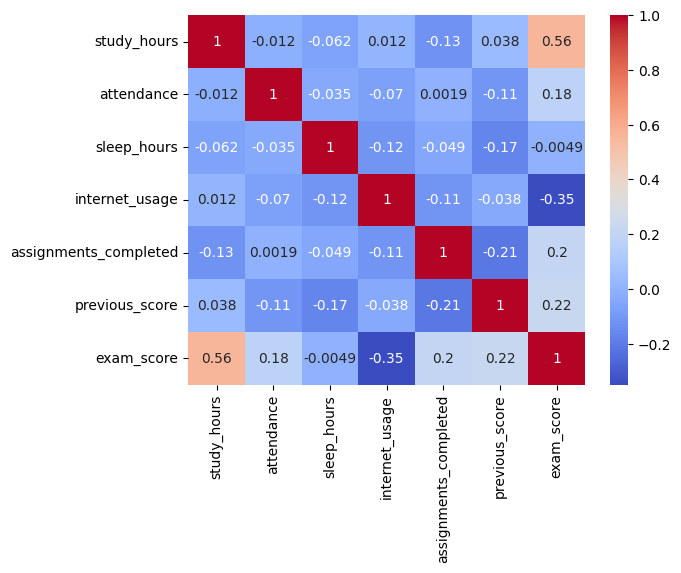

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapa de correlación
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [3]:
df_limpio = df[["study_hours", "internet_usage", "exam_score"]]
df_limpio.head()

,study_hours,internet_usage,exam_score
0,7,7,100.00
1,4,3,100.00
2,11,6,100.00
3,8,8,90.17
4,5,6,78.82


/tmp/ipykernel_48780/3225253804.py:44: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_scaled_sgd[:, 0], X_test_scaled_sgd[:, 1], c=y_test_sgd, cmap=ListedColormap(('darkred', 'darkgreen')), edgecolors='k', marker='x', s=100, label='Test data')


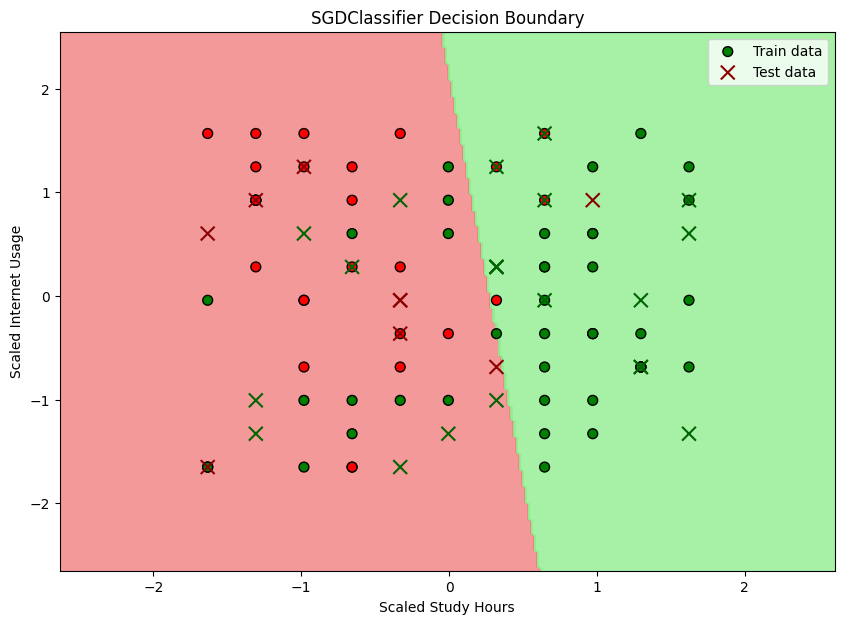

SGD Classifier Accuracy on Test Set: 0.7


In [7]:
from sklearn.linear_model import SGDClassifier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


# Convertir variables categóricas en variables dummies
usu_encoded = pd.get_dummies(df_limpio, drop_first=True)
usu_encoded['exam_pass'] = (usu_encoded['exam_score'] >= 90).astype(int)

# Variable objetivo binaria
X_score = usu_encoded.drop(["exam_score", "exam_pass"], axis=1)
y_score = usu_encoded["exam_pass"]

X_train_sgd, X_test_sgd, y_train_sgd, y_test_sgd = train_test_split(X_score, y_score, test_size=0.3, random_state=42)

scaler_sgd = StandardScaler()
X_train_scaled_sgd = scaler_sgd.fit_transform(X_train_sgd)
X_test_scaled_sgd = scaler_sgd.transform(X_test_sgd)

# Entrenamiento de SGDClassifier
sgd_clf = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001, max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train_scaled_sgd, y_train_sgd)

# Limites del gráfico
x_min, x_max = X_train_scaled_sgd[:, 0].min() - 1, X_train_scaled_sgd[:, 0].max() + 1
y_min, y_max = X_train_scaled_sgd[:, 1].min() - 1, X_train_scaled_sgd[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predicción de probabilidades
Z = sgd_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Color
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(('lightcoral', 'lightgreen')))
plt.scatter(X_train_scaled_sgd[:, 0], X_train_scaled_sgd[:, 1], c=y_train_sgd, cmap=ListedColormap(('red', 'green')), edgecolors='k', marker='o', s=50, label='Train data')
plt.scatter(X_test_scaled_sgd[:, 0], X_test_scaled_sgd[:, 1], c=y_test_sgd, cmap=ListedColormap(('darkred', 'darkgreen')), edgecolors='k', marker='x', s=100, label='Test data')

#Titulos
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('SGDClassifier Decision Boundary')
plt.xlabel('Scaled Study Hours')
plt.ylabel('Scaled Internet Usage')
plt.legend()
plt.show()

print("SGD Classifier Accuracy on Test Set:", sgd_clf.score(X_test_scaled_sgd, y_test_sgd))

Puntos Rojos: Desaprobó

Puntos Verdes: Aprobó

Area Roja: Predicción NO

Area verde: Prdicción SI

Cruz: Testeo

Puntos: Entrenamiento

Verdaderos Coinciden
Falsos No Coinciden

Falso Positivo: Predicción Negativa


Precisión (Accuracy): 76.00%


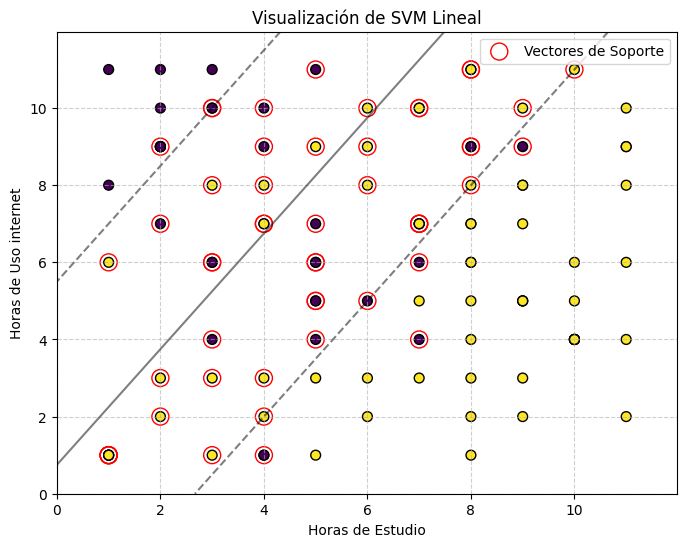

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

X = X_score.values
y = y_score.values

# Entrenamiento
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X, y)

# Espacio del gráfico
plt.figure(figsize=(8, 6))

# Puntos de los datos
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')

# Obtenemos los límites del gráfico
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predicción de clase para cada punto en el gráfico
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar la frontera de decisión (donde Z = 0)
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# La línea sólida es el hiperplano (0), las punteadas son los márgenes (-1 y 1)
# Graficar los Vectores
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='red', label='Vectores de Soporte')

# Títulos
plt.title('Visualización de SVM Lineal')
plt.xlabel('Horas de Estudio')
plt.ylabel('Horas de Uso internet')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

accuracy = clf.score(X, y)
print(f"Precisión (Accuracy): {accuracy * 100:.2f}%")
plt.show()



Puntos Violetas: Bajo rendimiento

Puntos Amarillos: Alto rendimiento

Linea Negra: Divide el modelo en 2

Trazo E paralelas: Margen

Circulos Rojos: Más dificiles de Clasificar  






SGDClassifier (Anterior): Busca minimizar el error global de todos los puntos. A veces puede permitir que puntos de una clase crucen la línea si eso reduce el error general.

SVM (Este gráfico): Se enfoca obsesivamente en maximizar el margen. No le importa tanto los puntos que están muy lejos de la línea (como los amarillos muy alejados a la derecha), sino los que están justo en el borde.